In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.svm import OneClassSVM
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import classification_report
%matplotlib inline
sns.set_style('darkgrid')

In [3]:
df1 = pd.read_csv("Algerian_forest_fires_dataset.csv")
df2 = pd.read_csv("forestfires.csv")

In [4]:
df1.sample(5)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classess
34,5,7,2012,33,66,14,0,85.9,7.6,27.9,4.8,9.1,4.9,fire
102,11,9,2012,30,77,21,1.8,58.5,1.9,8.4,1.1,2.4,0.3,not fire
177,24,7,2012,33,63,17,1.1,72.8,20.9,56.6,1.6,21.7,2.5,not fire
113,22,9,2012,31,50,19,0.6,77.8,10.6,41.4,2.4,12.9,2.8,not fire
183,30,7,2012,36,56,16,0,88.9,23.8,57.1,8.2,23.8,13.2,fire


In [5]:
df2.sample(5)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
188,6,4,mar,sat,90.8,41.9,89.4,7.9,13.3,42,0.9,0.0,7.40
150,6,5,jun,fri,92.5,56.4,433.3,7.1,23.2,39,5.4,0.0,1.19
365,6,5,sep,tue,91.9,111.7,770.3,6.5,19.6,45,3.1,0.0,20.03
240,6,3,apr,wed,88.0,17.2,43.5,3.8,15.2,51,2.7,0.0,0.00
258,3,4,aug,sat,91.8,170.9,692.3,13.7,20.6,59,0.9,0.0,0.00


In [6]:
df1=df1[['Temperature','RH','Rain','month','Ws','Classess']]

In [7]:
month_mapping = {
    'jan':1,'feb':2,'mar':3,'apr':4,
   'may':5,'jun':6,'jul':7,'aug':8,
    'sep':9,'oct':10,'nov':11,'dec':12
}
df2['month'] = df2['month'].map(month_mapping)

In [8]:
df2=df2[['temp','RH','rain','month','wind']]

In [9]:
df2=df2.rename(columns={'temp':'Temperature','wind':'Ws','rain':'Rain'})

In [10]:
df1.sample(5)

,Temperature,RH,Rain,month,Ws,Classess
183,36,56,0,7,16,fire
61,36,45,0,8,14,not fire
166,36,44,0,7,13,fire
20,30,78,0,6,14,fire
115,29,65,0.6,9,19,not fire


In [11]:
df2['Classess']='fire'

In [12]:
df = pd.concat([df1, df2], ignore_index=True)

In [13]:
df.sample(5)

,Temperature,RH,Rain,month,Ws,Classess
375,15.4,35,0.0,10,0.9,fire
576,24.2,27,0.0,9,3.1,fire
737,32.4,21,0.0,8,4.5,fire
309,20.8,33,0.0,8,2.7,fire
163,36,43,1.9,7,15,fire


In [14]:
df.describe()

,Temperature,RH,Rain,month,Ws,Classess
count,761,761,761.0,761,761.0,761
unique,212,138,47.0,17,40.0,3
top,35,27,0.0,8,2.2,fire
freq,29,33,509.0,184,53.0,654


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 763 entries, 0 to 762
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Temperature  761 non-null    object
 1   RH           761 non-null    object
 2   Rain         761 non-null    object
 3   month        761 non-null    object
 4   Ws           761 non-null    object
 5   Classess     761 non-null    object
dtypes: object(6)
memory usage: 35.9+ KB


In [16]:
df['month'].value_counts()

month
8        184
9        172
8         62
7         61
6         60
9         60
3         54
7         32
2         20
6         17
10        15
4          9
12         9
1          2
5          2
month      1
11         1
Name: count, dtype: int64

In [17]:
df=df[df['month']!= 'month']

In [18]:
df['month'] = pd.to_numeric(df['month'], errors='coerce')

In [19]:
df['month'].value_counts()

month
8.0     246
9.0     232
7.0      93
6.0      77
3.0      54
2.0      20
10.0     15
4.0       9
12.0      9
1.0       2
5.0       2
11.0      1
Name: count, dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 762 entries, 0 to 762
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  760 non-null    object 
 1   RH           760 non-null    object 
 2   Rain         760 non-null    object 
 3   month        760 non-null    float64
 4   Ws           760 non-null    object 
 5   Classess     760 non-null    object 
dtypes: float64(1), object(5)
memory usage: 41.7+ KB


In [21]:
df.dropna()

,Temperature,RH,Rain,month,Ws,Classess
0,29,57,0,6.0,18,not fire
1,29,61,1.3,6.0,13,not fire
2,26,82,13.1,6.0,22,not fire
3,25,89,2.5,6.0,13,not fire
4,27,77,0,6.0,16,not fire
...,...,...,...,...,...,...
758,27.8,32,0.0,8.0,2.7,fire
759,21.9,71,0.0,8.0,5.8,fire
760,21.2,70,0.0,8.0,6.7,fire
761,25.6,42,0.0,8.0,4.0,fire


In [22]:
df3=pd.read_csv('not_fire.csv')

In [23]:
df3=df3.rename(columns={'label':'Classess'})
df3['Classess']='not fire'

In [24]:
df3.sample()

,Temperature,RH,Rain,month,Ws,Classess
113,27,50,0,1,2,not fire


In [25]:
df = pd.concat([df, df3], ignore_index=True)

In [26]:
df['Classess'].value_counts()

Classess
fire        654
not fire    292
Name: count, dtype: int64

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 948 entries, 0 to 947
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  946 non-null    object 
 1   RH           946 non-null    object 
 2   Rain         946 non-null    object 
 3   month        946 non-null    float64
 4   Ws           946 non-null    object 
 5   Classess     946 non-null    object 
dtypes: float64(1), object(5)
memory usage: 44.6+ KB


In [28]:
from sklearn.preprocessing import OneHotEncoder

In [29]:
df=pd.get_dummies(df,columns=['Classess'])

In [30]:
df=df.drop('Classess_not fire', axis=1)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 948 entries, 0 to 947
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature    946 non-null    object 
 1   RH             946 non-null    object 
 2   Rain           946 non-null    object 
 3   month          946 non-null    float64
 4   Ws             946 non-null    object 
 5   Classess_fire  948 non-null    bool   
dtypes: bool(1), float64(1), object(4)
memory usage: 38.1+ KB


In [32]:
class_mapping = {
    True:1,False:0
}
df['Classess_fire'] = df['Classess_fire'].map(class_mapping)

In [33]:
df['RH'] = df['RH'].astype(float)
df['Temperature'] = df['Temperature'].astype(float)
df['Rain'] = df['Rain'].astype(float)
df['Ws'] = df['Ws'].astype(float)
df['Classess_fire'] = df['Classess_fire'].astype(int)


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 948 entries, 0 to 947
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature    946 non-null    float64
 1   RH             946 non-null    float64
 2   Rain           946 non-null    float64
 3   month          946 non-null    float64
 4   Ws             946 non-null    float64
 5   Classess_fire  948 non-null    int32  
dtypes: float64(5), int32(1)
memory usage: 40.9 KB


In [35]:
df.sample(2)

,Temperature,RH,Rain,month,Ws,Classess_fire
822,15.0,86.0,14.0,11.0,3.0,0
368,17.9,45.0,0.0,9.0,3.1,1


In [36]:
# from ydata_profiling import ProfileReport
# prof=ProfileReport(df)
# prof.to_file(output_file='output.html')

In [37]:
from scipy import stats

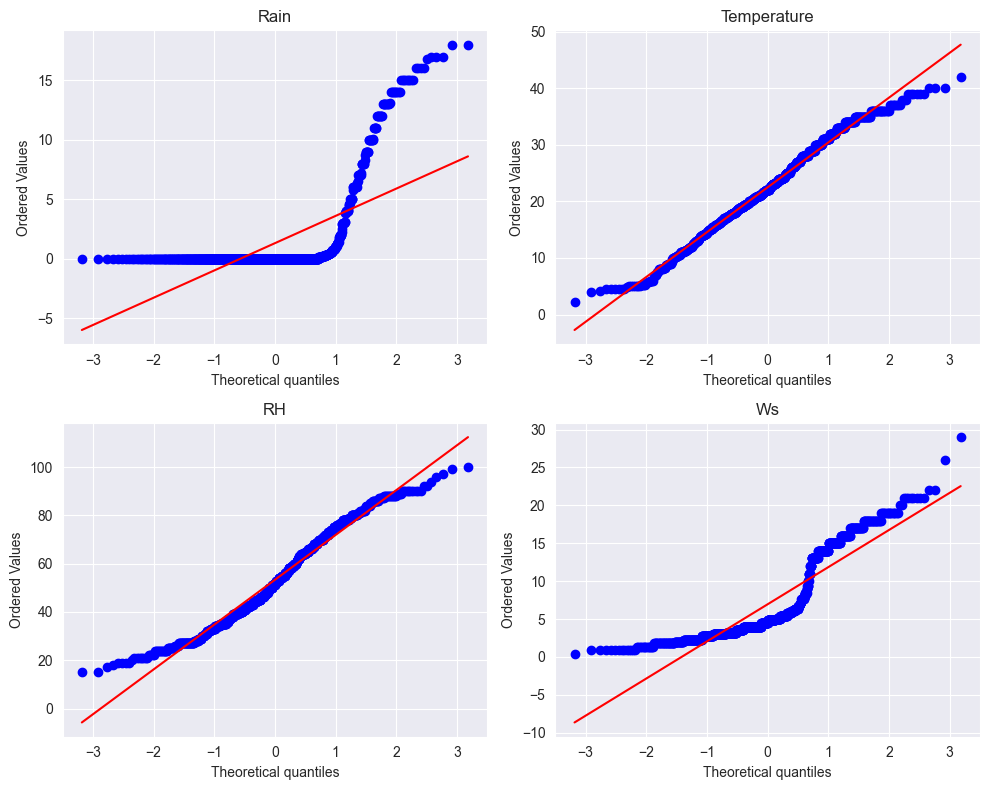

In [38]:
cols = ["Rain", "Temperature", "RH", "Ws"]

plt.figure(figsize=(10, 8))

for i, c in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    stats.probplot(df[c].dropna(), dist="norm", plot=plt)
    plt.title(c)

plt.tight_layout()
plt.show()

In [39]:
X=df.drop('Classess_fire', axis=1)
y=df['Classess_fire']

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

In [42]:
from sklearn.pipeline import Pipeline
from sklearn import set_config
set_config(display='diagram')
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [43]:
# import pandas as pd
# from sklearn.base import BaseEstimator, TransformerMixin

# class MonthToSeason(BaseEstimator, TransformerMixin):
#     def __init__(self, month_col="month"):
#         self.month_col = month_col

#     def fit(self, X, y=None):
#         return self

#     def transform(self, X):
#         X = X.copy()

#         def map_season(m):
#             if m in [12, 1, 2]:
#                 return "winter"
#             elif m in [3, 4, 5]:
#                 return "spring"
#             elif m in [6, 7, 8]:
#                 return "summer"
#             elif m in [9, 10, 11]:
#                 return "autumn"
#             else:
#                 return "unknown"

#         X["season"] = X[self.month_col].apply(map_season)
#         return X


In [44]:
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

# numeric_features = ["Temperature", "RH", "Ws", "Rain"]
# categorical_features = ["season"]

# preprocess = Pipeline(steps=[
#     ("month_to_season", MonthToSeason(month_col="month")),
#     ("encoder", ColumnTransformer(
#         transformers=[
#             ("num", "passthrough", numeric_features),
#             ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
#         ]
#     ))
# ])


In [45]:
scaler=StandardScaler()

In [46]:
import matplotlib.pyplot as plt
import scipy.stats as stats

def qq_plot(data, title):
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(title)
    plt.show()

In [47]:
RFC=RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

In [48]:
pipeline = Pipeline(steps=[
    # ("preprocess", preprocess),
    ("scaler", scaler),
    ("model", RFC)
])

In [49]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [50]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("Confusion Matrix (threshold = 0.5)")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Confusion Matrix (threshold = 0.5)
[[ 82   6]
 [  7 190]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.93      0.93        88
           1       0.97      0.96      0.97       197

    accuracy                           0.95       285
   macro avg       0.95      0.95      0.95       285
weighted avg       0.95      0.95      0.95       285

ROC-AUC: 0.9937125057683434


In [51]:
thresholds = [0.3, 0.4, 0.45, 0.5]

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(confusion_matrix(y_test, y_pred_t))
    print(classification_report(y_test, y_pred_t))



Threshold = 0.3
[[ 76  12]
 [  3 194]]
              precision    recall  f1-score   support

           0       0.96      0.86      0.91        88
           1       0.94      0.98      0.96       197

    accuracy                           0.95       285
   macro avg       0.95      0.92      0.94       285
weighted avg       0.95      0.95      0.95       285


Threshold = 0.4
[[ 80   8]
 [  6 191]]
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        88
           1       0.96      0.97      0.96       197

    accuracy                           0.95       285
   macro avg       0.95      0.94      0.94       285
weighted avg       0.95      0.95      0.95       285


Threshold = 0.45
[[ 81   7]
 [  6 191]]
              precision    recall  f1-score   support

           0       0.93      0.92      0.93        88
           1       0.96      0.97      0.97       197

    accuracy                           0.95       285
   macr

In [228]:
best_threshold = 0.5

y_final = (y_prob >= best_threshold).astype(int)

print("\nFINAL MODEL")
print(confusion_matrix(y_test, y_final))
print(classification_report(y_test, y_final))



FINAL MODEL
[[ 82   6]
 [  7 190]]
              precision    recall  f1-score   support

           0       0.92      0.93      0.93        88
           1       0.97      0.96      0.97       197

    accuracy                           0.95       285
   macro avg       0.95      0.95      0.95       285
weighted avg       0.95      0.95      0.95       285



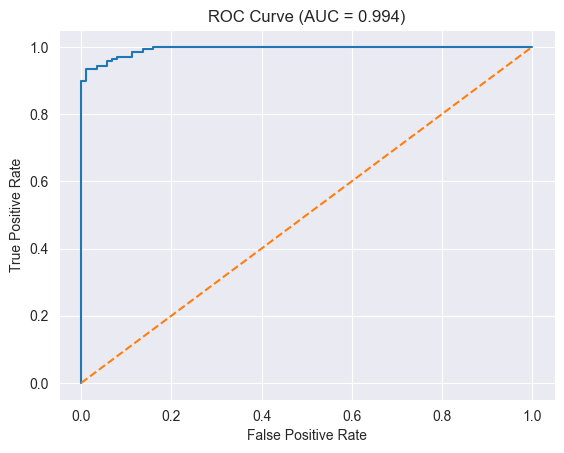

In [53]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.show()


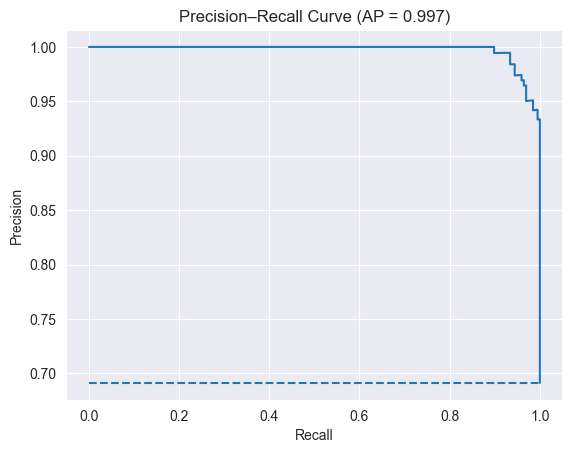

In [54]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

# Baseline precision
baseline = y_test.mean()

# Plot
plt.figure()
plt.plot(recall, precision)
plt.hlines(baseline, xmin=0, xmax=1, linestyles="--")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve (AP = {pr_auc:.3f})")
plt.show()


In [55]:
from sklearn.model_selection import cross_val_score,GridSearchCV

In [56]:
cross_val_score(pipeline,X_train,y_train,cv=5,scoring='accuracy').mean()

0.9623034859876967

In [57]:
cross_val_score(pipeline,X_train,y_train,cv=5,scoring='f1').mean()

0.972901892053839

In [58]:
cross_val_score(pipeline,X_train,y_train,cv=5,scoring='roc_auc').mean()

0.9875150451729757

In [59]:
params={
    'model__max_depth':[1,2,3,4,5,6,None]
}

In [60]:
# grid1=GridSearchCV(pipeline,params,cv=5,scoring='accuracy')

In [61]:
# grid1.fit(X_train,y_train)

In [62]:
# grid1.best_score_

In [63]:
# grid1.best_params_

In [64]:
# grid2=GridSearchCV(pipeline,params,cv=5,scoring='f1')
# grid2.fit(X_train,y_train)

In [65]:
# grid2.best_score_

In [66]:
# grid2.best_params_

In [67]:
# grid3=GridSearchCV(pipeline,params,cv=5,scoring='roc_auc')
# grid3.fit(X_train,y_train)

In [68]:
# grid3.best_score_

In [69]:
# grid3.best_params_

In [70]:
import pickle

with open("test.pkl", "wb") as f:
    pickle.dump(pipeline, f)

In [71]:

with open("test.pkl", "rb") as f:
    model = pickle.load(f)

In [72]:
type(model)

sklearn.pipeline.Pipeline

In [73]:
model.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('model',
   RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=300,
                          n_jobs=-1, random_state=42))],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'model': RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=300,
                        n_jobs=-1, random_state=42),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'model__bootstrap': True,
 'model__ccp_alpha': 0.0,
 'model__class_weight': 'balanced',
 'model__criterion': 'gini',
 'model__max_depth': 5,
 'model__max_features': 'sqrt',
 'model__max_leaf_nodes': None,
 'model__max_samples': None,
 'model__min_impurity_decrease': 0.0,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 2,
 'model__min_weight_fraction_leaf': 0.0,
 'model__monotonic_cst': None,
 'model__n_estimators': 300,
 'model__n_jobs': -1,
 'model__oob_score': False,
 'model__r

In [74]:
# model.n_features_in_


In [75]:
# X_t = np.array([[29,57,0,6.0,18]])  # shape: (1, 5)
# y_pred = model.predict(X_t)

# print(y_pred)

In [76]:

# X_t= np.array([[27.8,32,0.0,8.0,2.7]])  # shape: (1, 5)
# y_pred = model.predict(X_t)

# print(y_pred)

In [77]:
X_sample=df.drop('Classess_fire', axis=1).sample(10)
y_sample=df['Classess_fire'].sample(10)

In [78]:
model.score(X_sample,y_sample)

0.6

In [79]:
y_sample

4      0
712    1
436    1
287    1
5      1
60     1
501    1
905    0
372    1
640    1
Name: Classess_fire, dtype: int32

In [80]:
X_sample=df.drop('Classess_fire', axis=1).sample(10)
y_sample=df['Classess_fire'].sample(10)

In [81]:
model.score(X_train, y_train)

0.9743589743589743

In [82]:
model.score(X_test, y_test)

0.9543859649122807

In [83]:
X_test.shape

(285, 5)

In [84]:
y_test.shape

(285,)

In [85]:
type(y_test)

pandas.core.series.Series

In [86]:
test_cases = [
    [38, 15, 0, 6, 20],
    [30, 70, 5, 7, 10],
    [5, 80, 10, 12, 5],
    [28, 25, 0, 4, 15],
    [35, 65, 12, 5, 5],
    [33, 20, 0, 10, 30],
    [30, 40, 1, 8, 10],
    [40, 10, 0, 7, 25],
    [25, 50, 0, 9, 5],
    [32, 30, 0, 3, 15],
    [20, 60, 2, 11, 10],
    [37, 12, 0, 8, 20],
    [15, 70, 5, 1, 5],
    [29, 35, 0, 5, 12],
    [26, 55, 3, 2, 8],
    [39, 10, 0, 9, 30],
    [22, 65, 7, 12, 5],
    [34, 25, 0, 6, 18],
    [27, 45, 2, 7, 12],
    [31, 20, 0, 8, 20],
    [32, 30, 0, 2, 2.63]
]

In [87]:
df_test = pd.DataFrame(test_cases, columns=["Temperature","RH","Rain","month","Ws"])


In [88]:
predictions = pipeline.predict(df_test)

In [89]:
predictions

array([1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

In [90]:
expeced=[1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

In [91]:
model.predict(df_test)

array([1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

In [ ]:
[1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
[1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

In [92]:
model.score(test_cases, expeced)

C:\APPS\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


0.8571428571428571

In [222]:
abc=pd.DataFrame([[30,80,8,8,3]], columns=["Temperature","RH","Rain","month","Ws"])

In [224]:
model.predict(abc)

array([0])

In [95]:
import pickle

with open("rfc_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline, f)